<a href="https://colab.research.google.com/github/m9ts/AsimovAcademy_AnaliseDeDados/blob/main/analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de dados - Portal da Transparência

In [ ]:
ano = 2023
path = f'/content/drive/MyDrive/Asimov/{ano}_Viagem.csv'
path_saida_tabela = f'/content/drive/MyDrive/Asimov/output/tabela_{ano}.xlsx'
path_saida_grafico = f'/content/drive/MyDrive/Asimov/output/grafico_{ano}.png'

In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Lendo os dados do dataset
df_viagens = pd.read_csv(path, encoding="Windows-1252", sep = ";", decimal = ",")

# Criando nova coluna de despesas
df_viagens['Despesas'] = df_viagens['Valor diárias'] + df_viagens['Valor passagens'] + df_viagens['Valor outros gastos']

# Ajustando valores nulos na coluna de cargo
df_viagens['Cargo'] = df_viagens['Cargo'].fillna("NÃO IDENTIFICADO")

# Convertendo colunas de datas
df_viagens['Período - Data de início'] = pd.to_datetime(df_viagens['Período - Data de início'], format = "%d/%m/%Y")
df_viagens['Período - Data de fim'] = pd.to_datetime(df_viagens['Período - Data de fim'], format = "%d/%m/%Y")

# Criando novas colunas de datas
df_viagens['Mês da viagem'] = df_viagens['Período - Data de início'].dt.month_name()
df_viagens['Dias de duração da viagem'] = (df_viagens['Período - Data de fim'] - df_viagens['Período - Data de início']).dt.days

# Criando tabela consolidada
df_viagens_consolidado = (
    df_viagens
    .groupby('Cargo')
    .agg(
        despesa_media = ('Despesas', 'mean'),
        duracao_media = ('Dias de duração da viagem', 'mean'),
        despesas_totais = ('Despesas', 'sum'),
        destino_mais_frequente = ('Destinos', pd.Series.mode),
        n_viagens = ('Nome', 'count')
        )
    .reset_index()
    )

# Filtrando tabela consolidada por cargos relevantes ( > 1% das viagens)
df_cargos = df_viagens['Cargo'].value_counts(normalize = True).reset_index()
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']
filtro = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)

# Chegando na tabela final - consolidada e filtrada
df_final = df_viagens_consolidado[filtro].sort_values(by = 'n_viagens', ascending = False)


In [ ]:
df_viagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de duração da viagem
0,17821923,000001/23-1C,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26352,Fundação Universidade Federal do ABC,***.875.238-**,PRISCILA LEAL DA SILVA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2023-01-01,2023-12-02,Loughborough/Reino Unido,Intercâmbio acadêmico PCDP anterior 07/21-3C,0.00,0.00,0.00,0.00,0.00,January,335
1,18159396,000001/23,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26271,Fundação Universidade de Brasília,***.000.000-**,Ekaterina Pavlovskaia,NÃO IDENTIFICADO,-1,Sem informação,2023-02-25,2023-03-06,Pirenópolis/GO,Segue abaixo cópia da carta-convite enviada à ...,0.00,7894.50,0.00,0.00,7894.50,February,9
2,18236583,000018/23,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,***.280.677-**,CAMILLA DUARTE DA SILVA,BIBLIOTECARIO-DOCUMENTALISTA,-1,Sem informação,2023-01-16,2024-02-28,Rio de Janeiro/RJ,Afastamento para pós-graduação stricto sensu n...,0.00,0.00,0.00,0.00,0.00,January,408
3,18288418,000007/23-1C,Realizada,SIM,Por necessidade do serviço.,52000,Ministério da Defesa,52121,Comando do Exército,***.621.358-**,ANDRE LUIS COSTA PITANGUEIRA,NÃO IDENTIFICADO,OfSuperior,OfSuperior,2023-01-10,2023-01-29,Nova York/Estados Unidos da América,Participar da revisão do COE Manual (Contingen...,39565.70,7434.13,0.00,1095.35,48095.18,January,19
4,18296348,000070/23,Realizada,SIM,A efetivação do empenho no Siafi e a respectiv...,26000,Ministério da Educação,26406,"Instituto Federal de Educação, Ciência e Tecno...",***.407.547-**,LIDIANY MIRANDA FERRAZ NUNES,AUXILIAR DE BIBLIIOTECA,-1,Sem informação,2023-02-05,2023-02-10,Vitória/ES,Participação das aulas de Mestrado Interinstit...,1013.96,0.00,0.00,0.00,1013.96,February,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833052,2023001618,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.748.269-**,BIANCA VIANA CARDOSO KIVEL,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2023-12-05,2023-12-06,Sem informação,Participar de tratativas nos locais das reuniõ...,606.89,3331.29,0.00,0.00,3938.18,December,1
833053,2023001619,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.231.806-**,LUCAS ALVES FREIRE,PROCURADOR DO BANCO CENTRAL,-1,Sem informação,2023-12-11,2023-12-13,Sem informação,Participar da reunião do COPOM .,1089.00,1837.18,0.00,0.00,2926.18,December,2
833054,2023001628,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.632.011-**,SERGIO BOTELHO,TECNICO DO BANCO CENTRAL,-1,Sem informação,2023-12-07,2023-12-08,Sem informação,Acompanhamento do Presidente do BC - São Paulo,734.13,4555.95,0.00,0.00,5290.08,December,1
833055,2023001631,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.407.445-**,NELSON CAMPOS REIS JUNIOR,TECNICO DO BANCO CENTRAL,-1,Sem informação,2023-12-11,2023-12-11,Sem informação,Acompanhamento do Presidente - São Paulo.,319.28,3745.53,0.00,400.00,4464.81,December,0


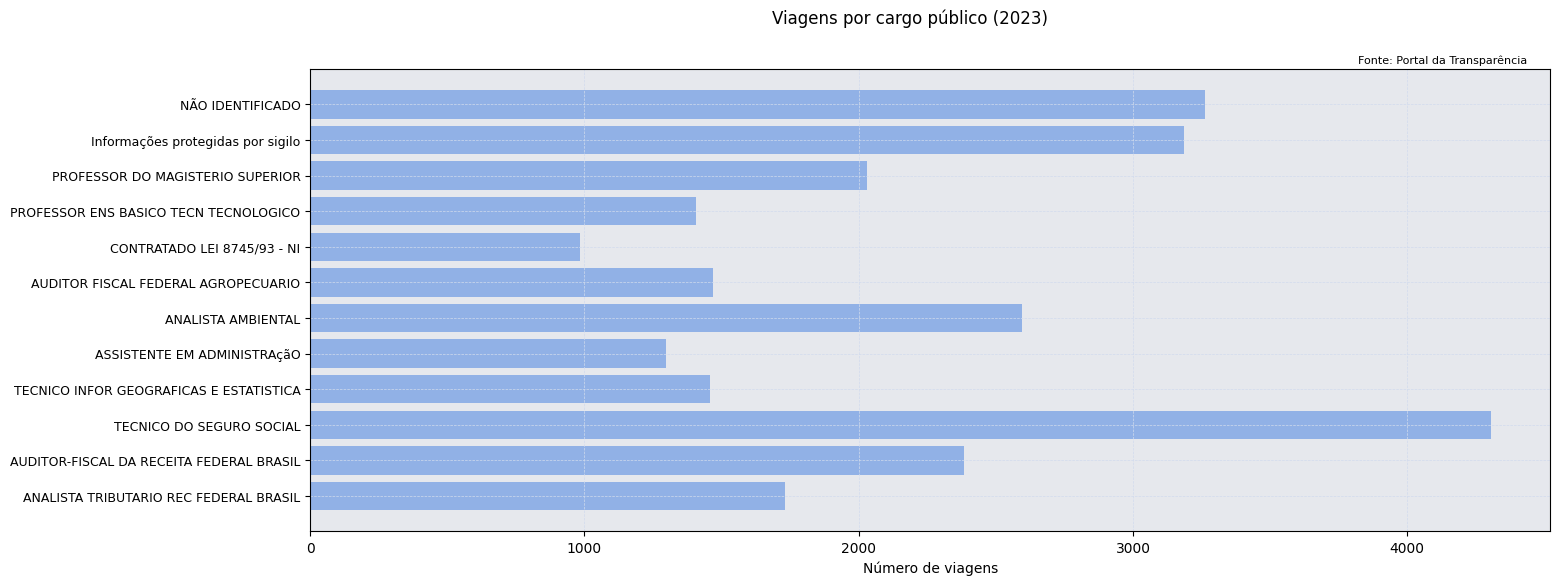

In [ ]:
import matplotlib.pyplot as plt

# Criando a figura
fig, ax = plt.subplots(figsize = (16, 6))

# Plotando o gráfico
ax.barh(df_final['Cargo'], df_final['despesa_media'], color = '#91b1e6')
ax.invert_yaxis()

# Ajustando o gráfico
ax.set_facecolor('#e6e8ed')
fig.suptitle('Viagens por cargo público (2023)')
plt.figtext(0.78, 0.89,'Fonte: Portal da Transparência', fontsize = 8)
plt.grid(color = '#d1dbed', linestyle = '--', linewidth = 0.5)
plt.yticks(fontsize = 9)
plt.xlabel('Número de viagens')

# Exibindo o gráfico
# plt.show()

# Salvando a tabela final
df_final.to_excel(path_saida_tabela, index = False)

# Salvando o gráfico
plt.savefig(path_saida_grafico, bbox_inches = 'tight')